# 02 · EDA & Cleaning

This notebook covers the second phase of the Barcelona Housing Affordability Analysis:

- Missing value analysis across all three datasets
- Outlier detection in cadastral values and household income
- Feature engineering: affordability index and dwelling size score

**Input:** Cleaned CSVs from `data/processed/`  
**Output:** Enriched dataset ready for analysis in notebook 03

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"

df_cadastral = pd.read_csv(PROCESSED / "cadastral_values_clean.csv")
df_surface   = pd.read_csv(PROCESSED / "housing_surface_clean.csv")
df_income    = pd.read_csv(PROCESSED / "household_income_clean.csv")

print(f"Cadastral values : {df_cadastral.shape}")
print(f"Housing surface  : {df_surface.shape}")
print(f"Household income : {df_income.shape}")

Cadastral values : (32040, 8)
Housing surface  : (32314, 8)
Household income : (5340, 7)


## 1. Missing Value Analysis

In [6]:
def missing_value_report(df, name):
    total = df.isnull().sum()
    pct = (total / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': total, 'pct': pct})
    report = report[report['missing'] > 0]
    if report.empty:
        print(f"{name}: no missing values ✓")
    else:
        print(f"\n{name}:")
        print(report)

missing_value_report(df_cadastral, "Cadastral values")
missing_value_report(df_surface,   "Housing surface")
missing_value_report(df_income,    "Household income")

Cadastral values: no missing values ✓
Housing surface: no missing values ✓
Household income: no missing values ✓


## 2. Descriptive Statistics

In [8]:
print("=== CADASTRAL VALUES — unit_cadastral_value_eur_m2 ===")
print(df_cadastral[df_cadastral['value_type'] == 'unit_cadastral_value_eur_m2']['value']
      .describe().to_frame().T)

print("\n=== HOUSING SURFACE — housing_count ===")
print(df_surface['housing_count'].describe().to_frame().T)

print("\n=== HOUSEHOLD INCOME — income_per_capita ===")
print(df_income['income_per_capita'].describe().to_frame().T)

=== CADASTRAL VALUES — unit_cadastral_value_eur_m2 ===
         count   mean    std    min    25%    50%      75%      max
value 5,340.00 950.21 285.28 313.25 760.50 902.23 1,122.07 2,079.22

=== HOUSING SURFACE — housing_count ===
                  count   mean    std  min  25%   50%    75%      max
housing_count 32,314.00 126.66 155.32 1.00 9.00 55.00 206.00 1,075.00

=== HOUSEHOLD INCOME — income_per_capita ===
                     count      mean      std      min       25%       50%  \
income_per_capita 5,340.00 22,164.44 6,502.23 7,652.00 17,998.50 21,262.50   

                        75%       max  
income_per_capita 24,842.25 45,791.00  


## 3. Outlier Detection

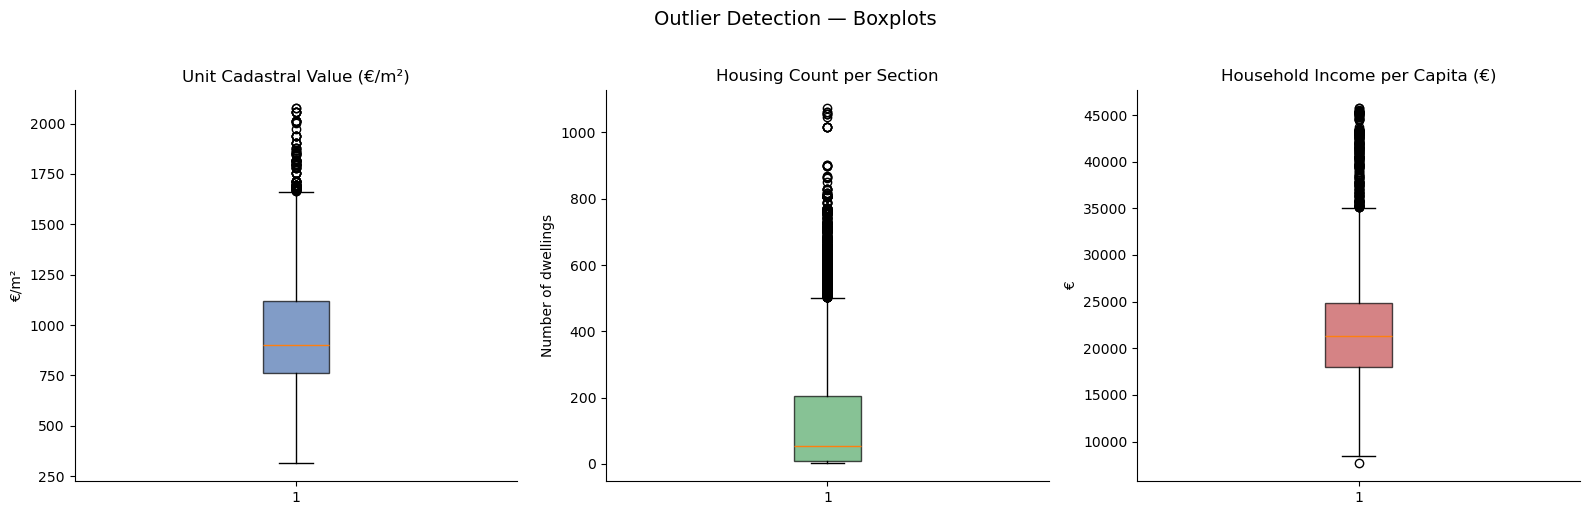

Plot saved to visualizations/


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cadastral unit value
df_unit = df_cadastral[df_cadastral['value_type'] == 'unit_cadastral_value_eur_m2']
axes[0].boxplot(df_unit['value'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[0].set_title('Unit Cadastral Value (€/m²)')
axes[0].set_ylabel('€/m²')

# Housing count
axes[1].boxplot(df_surface['housing_count'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#55A868', alpha=0.7))
axes[1].set_title('Housing Count per Section')
axes[1].set_ylabel('Number of dwellings')

# Household income
axes[2].boxplot(df_income['income_per_capita'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#C44E52', alpha=0.7))
axes[2].set_title('Household Income per Capita (€)')
axes[2].set_ylabel('€')

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'visualizations' / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to visualizations/")

In [11]:
def iqr_outlier_report(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}:")
    print(f"  IQR range : [{lower:,.2f} — {upper:,.2f}]")
    print(f"  Outliers  : {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
    print(f"  Max value : {series.max():,.2f}")
    print()

iqr_outlier_report(df_unit['value'], "Unit Cadastral Value (€/m²)")
iqr_outlier_report(df_surface['housing_count'], "Housing Count per Section")
iqr_outlier_report(df_income['income_per_capita'], "Household Income per Capita (€)")

Unit Cadastral Value (€/m²):
  IQR range : [218.13 — 1,664.43]
  Outliers  : 119 (2.23%)
  Max value : 2,079.22

Housing Count per Section:
  IQR range : [-286.50 — 501.50]
  Outliers  : 988 (3.06%)
  Max value : 1,075.00

Household Income per Capita (€):
  IQR range : [7,732.88 — 35,107.88]
  Outliers  : 265 (4.96%)
  Max value : 45,791.00



## 4. Outlier Analysis

Outliers are present in all three datasets but represent legitimate geographic variation across Barcelona's census sections:

- **Unit cadastral value:** 2.23% of sections exceed the IQR upper bound, corresponding to premium areas (Sarrià, Dreta de l'Eixample). Max: €2,079/m²
- **Housing count:** Sections with very few dwellings reflect mixed-use or industrial census sections. Large sections reach 1,075 dwellings.
- **Household income:** The range (€7,652 — €45,791) captures the structural inequality this project aims to analyse.

**Decision: no outliers removed.** All values are geographically explainable and analytically relevant.

## 5. Feature Engineering

We build three new analytical features:

1. **`affordability_ratio`** — unit cadastral value divided by income per capita. Higher = less affordable.
2. **`pct_small_dwellings`** — share of dwellings under 60m² per census section and year.
3. **`affordability_category`** — district-level classification based on affordability ratio quartiles.

In [14]:
# Aggregate cadastral values to census section level (unit value only)
df_unit = (
    df_cadastral[df_cadastral['value_type'] == 'unit_cadastral_value_eur_m2']
    .groupby(['year', 'district_id', 'district_name', 
              'neighbourhood_id', 'neighbourhood_name', 'census_section'])
    ['value'].mean()
    .reset_index()
    .rename(columns={'value': 'unit_cadastral_value'})
)

# Aggregate income to census section level
df_inc = (
    df_income
    .groupby(['year', 'district_id', 'district_name',
              'neighbourhood_id', 'neighbourhood_name', 'census_section'])
    ['income_per_capita'].mean()
    .reset_index()
)

# Aggregate small dwellings share to census section level
df_small = (
    df_surface
    .groupby(['year', 'district_id', 'district_name',
              'neighbourhood_id', 'neighbourhood_name', 'census_section'])
    [['housing_count', 'surface_range']]
    .apply(lambda x: pd.Series({
        'total_dwellings': x['housing_count'].sum(),
        'small_dwellings': x.loc[
            x['surface_range'].isin(['Up to 30 m2', '31-60 m2']),
            'housing_count'
        ].sum()
    }), include_groups=False)
    .reset_index()
)
df_small['pct_small_dwellings'] = (
    df_small['small_dwellings'] / df_small['total_dwellings'] * 100
).round(2)

print(f"Unit cadastral : {df_unit.shape}")
print(f"Income         : {df_inc.shape}")
print(f"Small dwellings: {df_small.shape}")

Unit cadastral : (5340, 7)
Income         : (5340, 7)
Small dwellings: (5340, 9)


In [15]:
# Merge keys — use numeric IDs only to avoid string inconsistencies
MERGE_KEYS = ['year', 'district_id', 'neighbourhood_id', 'census_section']

# Merge all three datasets
df_master = (
    df_unit
    .merge(df_inc[MERGE_KEYS + ['income_per_capita']],   on=MERGE_KEYS)
    .merge(df_small[MERGE_KEYS + ['total_dwellings', 
                    'small_dwellings', 'pct_small_dwellings']], on=MERGE_KEYS)
)

# Feature 1: Affordability ratio (unit cadastral value / income per capita)
df_master['affordability_ratio'] = (
    df_master['unit_cadastral_value'] / df_master['income_per_capita']
).round(4)

# Feature 2: Affordability category based on yearly quartiles
df_master['affordability_category'] = df_master.groupby('year')['affordability_ratio'].transform(
    lambda x: pd.qcut(x, q=4, labels=['Affordable', 'Moderate', 'Pressured', 'Critical'])
)

print(f"Master dataset shape: {df_master.shape}")
print(f"Districts     : {df_master['district_id'].nunique()}")
print(f"Neighbourhoods: {df_master['neighbourhood_id'].nunique()}")
print(f"Census sections: {df_master['census_section'].nunique()}")
print(f"\nColumns: {list(df_master.columns)}")

Master dataset shape: (5340, 13)
Districts     : 10
Neighbourhoods: 73
Census sections: 181

Columns: ['year', 'district_id', 'district_name', 'neighbourhood_id', 'neighbourhood_name', 'census_section', 'unit_cadastral_value', 'income_per_capita', 'total_dwellings', 'small_dwellings', 'pct_small_dwellings', 'affordability_ratio', 'affordability_category']


In [16]:
print("=== MASTER DATASET SAMPLE (2022) ===")
print(df_master[df_master['year'] == 2022]
      [['district_name', 'neighbourhood_name', 'unit_cadastral_value',
        'income_per_capita', 'pct_small_dwellings', 
        'affordability_ratio', 'affordability_category']]
      .sort_values('affordability_ratio', ascending=False)
      .head(10)
      .to_string(index=False))

print("\n=== LEAST AFFORDABLE (2022) ===")
print(df_master[df_master['year'] == 2022]
      [['neighbourhood_name', 'affordability_ratio', 'affordability_category']]
      .sort_values('affordability_ratio', ascending=False)
      .head(5)
      .to_string(index=False))

print("\n=== MOST AFFORDABLE (2022) ===")
print(df_master[df_master['year'] == 2022]
      [['neighbourhood_name', 'affordability_ratio', 'affordability_category']]
      .sort_values('affordability_ratio', ascending=True)
      .head(5)
      .to_string(index=False))

=== MASTER DATASET SAMPLE (2022) ===
district_name neighbourhood_name  unit_cadastral_value  income_per_capita  pct_small_dwellings  affordability_ratio affordability_category
 Ciutat Vella     la Barceloneta              1,365.77          17,877.00                65.78                 0.08               Critical
 Ciutat Vella           el Raval                807.89          10,692.00                76.21                 0.08               Critical
 Ciutat Vella           el Raval                846.18          11,708.00                75.91                 0.07               Critical
 Ciutat Vella     la Barceloneta              1,170.90          16,281.00                92.37                 0.07               Critical
 Ciutat Vella     la Barceloneta              1,230.20          17,188.00                83.07                 0.07               Critical
 Ciutat Vella     la Barceloneta              1,196.15          17,278.00                91.89                 0.07              

## 6. Save Enriched Dataset

In [18]:
output_path = PROCESSED / "master_dataset.csv"
df_master.to_csv(output_path, index=False)

print("Enriched dataset saved to data/processed/")
print(f"\nShape : {df_master.shape}")
print(f"Period: {df_master['year'].min()} — {df_master['year'].max()}")
print(f"Districts   : {df_master['district_id'].nunique()}")
print(f"Neighbourhoods: {df_master['neighbourhood_id'].nunique()}")
print(f"Census sections: {df_master['census_section'].nunique()}")

Enriched dataset saved to data/processed/

Shape : (5340, 13)
Period: 2018 — 2022
Districts   : 10
Neighbourhoods: 73
Census sections: 181


## 7. Summary

### Missing values
No missing values found in any of the three datasets.

### Outliers
Outliers are present in all datasets but represent legitimate geographic variation. No values were removed — they are analytically relevant to the affordability narrative.

| Variable | Outliers | Decision |
|---|---|---|
| Unit cadastral value (€/m²) | 2.23% | Kept — premium census sections |
| Housing count per section | 3.06% | Kept — large residential blocks |
| Household income per capita (€) | 4.96% | Kept — structural inequality |

### Feature engineering
Two new features were created:

- **`affordability_ratio`** — unit cadastral value / income per capita. Ranges from 0.02 (most affordable) to 0.08 (least affordable) in 2022.
- **`affordability_category`** — quartile-based classification per year: Affordable / Moderate / Pressured / Critical.

### Key observation
La Barceloneta and el Raval consistently appear as the least affordable census sections — high cadastral values combined with low household income and a very high share of small dwellings. El Poblenou and Torre Baró show the most affordable profiles.

### Next steps
- `03_affordability_analysis.ipynb` — visualisations by district and neighbourhood
- `04_clustering.ipynb` — K-Means clustering by affordability profile

In [20]:
print("Notebook 02 complete.")
print("\nOutputs saved to data/processed/")
print("  - master_dataset.csv")

Notebook 02 complete.

Outputs saved to data/processed/
  - master_dataset.csv
